# Data Understanding

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("../data/raw/paysim.csv")

# overview
print("datset size:", df.shape)
print(df.info())
df.head()

datset size: (6362620, 11)
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB
None


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.describe(include="all")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C2098525306,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


In [3]:
# missing values + check for dupcs
print("duplicates:", df.duplicated().sum())
df.isna().sum()

duplicates: 0


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

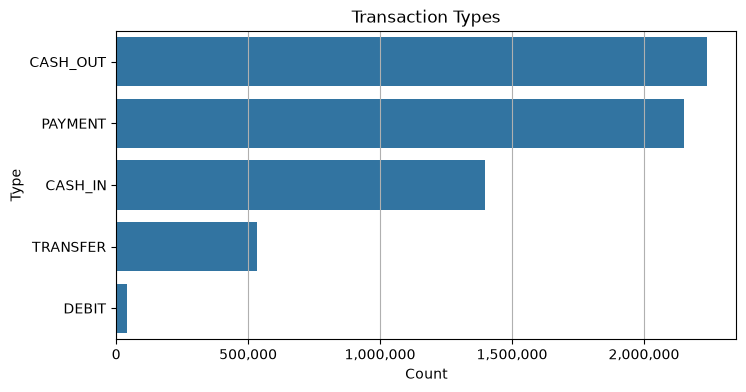

In [4]:
# transaction types
transaction_types = df.groupby("type").agg(
    count=("amount", "count")
).sort_values(by="count", ascending=False)

from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(8,4))
ax = sns.barplot(data=transaction_types, x="count", y="type")
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Transaction Types")
plt.xlabel("Count"); plt.ylabel("Type")
plt.grid(axis="x")
plt.show()

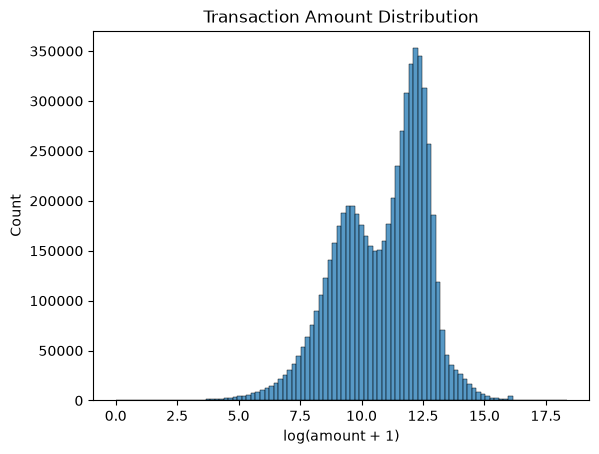

In [12]:
# amount distribution
import numpy as np

sns.histplot(np.log1p(df["amount"]), bins=100)
plt.xlabel("log(amount + 1)")
plt.title("Transaction Amount Distribution")
plt.show()

In [6]:
# target distribution
pd.DataFrame({
    "Count": df["isFraud"].value_counts(),
    "Percentage": df["isFraud"].value_counts(normalize=True).mul(100).round(3)
})

,Count,Percentage
isFraud,,
0,6354407,99.871
1,8213,0.129


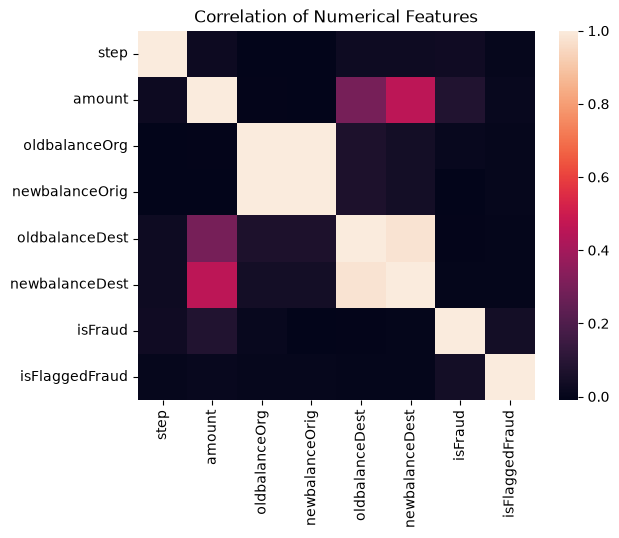

In [7]:
# correlation matrix for numerical features
corr = df.corr(numeric_only=True)
sns.heatmap(corr)
plt.title("Correlation of Numerical Features")
plt.show()

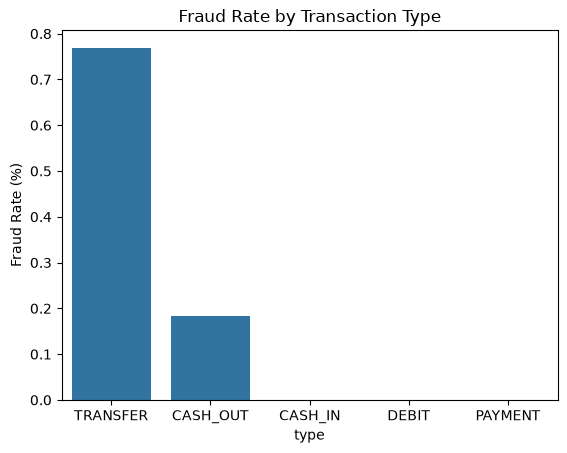

,type,fraud_rate
4,TRANSFER,0.768799
1,CASH_OUT,0.183955
0,CASH_IN,0.000000
2,DEBIT,0.000000
3,PAYMENT,0.000000


In [15]:
# fraud by transaction type
fraud_rate = (
    df.groupby("type")["isFraud"].mean().mul(100)
    .reset_index(name="fraud_rate")
    .sort_values(ascending=False, by="fraud_rate")
)

ax = sns.barplot(data=fraud_rate, x="type", y="fraud_rate")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Type")
plt.show()

fraud_rate.sort_values("fraud_rate", ascending=False)

In [9]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [10]:
(df["oldbalanceOrg"] < df["amount"]).sum()

np.int64(4079080)

In [11]:
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

# Observations

1. 6,362,620 items and 11 features

2. amount mean = 179861 and median = 74871 and max = 92445516

3. same pattern as amount for oldBalanceOrg, oldBalanceDest, newBalanceDest

4. nunique report: nameOrig = 6353307 - nameDest = 2722362


# Findings

1. no missing values or duplicates

2. dataset is dominated by CASH_OUT and PAYMENT transactions, indicating a highly imbalanced distribution across transaction types

3. transaction amounts are heavily right-skewed, suggesting that logarithmic transformation should be considered during preprocessing and visualization

7. only 0.129% fraud (8213) while we have 99.871% normal transactions

8. correlation: newBalanceOrig - oldBalanceOrg and newBalanceDest - oldBalanceDest are near 1
 - these variables likely contain redundant information and should be investigated before model training

[9. correlation between oldBalanceDest - amount is near 0.3]: #

[10. correlation between newBalanceDest - amount is near 0.4]: #

[11. correlation between isFraud - amount is near 0.1]: #

12. 0.769 of fraud is by transfer and 0.184 is by cash out while we have no fraud by other transaction types
 - fraud occurs almost exclusively in TRANSFER and CASH_OUT transactions

13. (df["oldbalanceOrg"] < df["amount"]).sum() shows 4,079,080
 - seems interesting, should be discovered

14. df.groupby("isFraud")["amount"].describe() -> mean (isFraud = 0) = 178197 - mean (isFraud = 1) = 1467967
 - meaning that frauds almost have larger amounts


# Hypothesis

1. transactions that empty the sender's account are more likely to be fraudulent

2. the ratio between transaction amount and sender balance is predictive of fraud

3. large TRANSFER transactions are significantly more likely to be fraudulent than other transaction types

4. sudden increases in destination balance may indicate fraudulent behavior